# π₀.₇ — end-to-end assembly

Wire up the full steerable-generalist stack from the ground up using the in-repo `TinyBackbone`. Real PaliGemma / Gemma 3 weights are gated behind ≥12 GB VRAM; this notebook runs on an Apple Silicon Mac in seconds.

Five context channels exercised:
1. Vision (images) + language + proprioceptive state — the π₀ backbone.
2. Subtask token head — the π₀.₅ addition.
3. Advantage-conditioning token — the π*₀.₆ addition.
4. Subgoal images + episode metadata — the π₀.₇ additions.
5. MEM long-term recall tokens — π₀.₇ + MEM integration.

Paper: `papers/2026-04-16_pi07_steerable-model-emergent-capabilities.pdf`

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from pi_stack.memory.mem import MEM, MEMConfig
from pi_stack.models.action_expert import ActionExpertConfig
from pi_stack.models.backbones import TINY
from pi_stack.models.pi07 import (
    Persona, Pi07Config, Pi07Policy, Quality, Speed,
)
from pi_stack.training.recap import AdvantageConditioner, RECAPConfig

torch.manual_seed(0)
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print('device:', device)

device: mps


## 1. Build a tiny π₀.₇

All dims are small so the whole forward pass runs in <1s on CPU. Real PaliGemma 3B is the same interface.

In [2]:
cfg = Pi07Config(
    backbone=TINY,
    action_expert=ActionExpertConfig(
        hidden_size=128, num_layers=2, num_heads=4,
        action_dim=7, horizon=20, flow_steps=5, time_embed_dim=64,
    ),
    state_dim=14, image_resolution=64,
    advantage_token_dim=64,
    use_subgoal_images=True, use_episode_metadata=True, use_mem=True,
    memory=MEMConfig(embedding_dim=64),
)
policy = Pi07Policy(cfg)

total_params = sum(p.numel() for p in policy.parameters())
print(f'total params              : {total_params:>10,d}')
print(f'  backbone                : {sum(p.numel() for p in policy.backbone.parameters()):>10,d}')
print(f'  state encoder           : {sum(p.numel() for p in policy.state_encoder.parameters()):>10,d}')
print(f'  action expert           : {sum(p.numel() for p in policy.action_expert.parameters()):>10,d}')
print(f'  subtask head            : {sum(p.numel() for p in policy.subtask_head.parameters()):>10,d}')
print(f'  advantage projection    : {sum(p.numel() for p in policy.advantage_proj.parameters()):>10,d}')
print(f'  subgoal projection      : {sum(p.numel() for p in policy.subgoal_proj.parameters()):>10,d}')
print(f'  metadata embeddings     : {sum(p.numel() for p in policy.speed_embed.parameters()) + sum(p.numel() for p in policy.quality_embed.parameters()) + sum(p.numel() for p in policy.persona_embed.parameters()):>10,d}')
print(f'  memory projection       : {sum(p.numel() for p in policy.mem_proj.parameters()):>10,d}')

total params              :  1,541,895
  backbone                :    792,960
  state encoder           :     18,432
  action expert           :    539,399
  subtask head            :    132,096
  advantage projection    :      8,320
  subgoal projection      :     33,024
  metadata embeddings     :      1,152
  memory projection       :     16,512


## 2. Single-batch inference

Bare π₀-style forward — no advantage / subgoal / metadata / MEM extras yet.

In [3]:
B = 4
images = torch.randn(B, 3, cfg.image_resolution, cfg.image_resolution)
state = torch.randn(B, cfg.state_dim)
language_ids = torch.randint(0, TINY.vocab_size, (B, 8))

with torch.no_grad():
    chunk = policy.predict_chunk(images, state, language_ids)
print('chunk shape    :', chunk.shape)
print('action range   : [%.3f, %.3f]' % (chunk.min().item(), chunk.max().item()))

chunk shape    : torch.Size([4, 20, 7])
action range   : [-3.485, 3.423]


## 3. Metadata steering

Hold all other inputs fixed; vary the speed/quality/persona buckets. Different metadata should produce different action chunks.

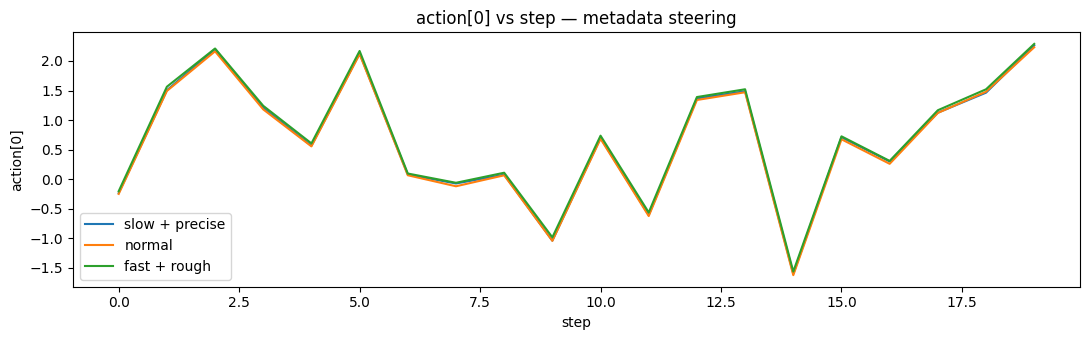

In [4]:
torch.manual_seed(0)
images_1   = torch.randn(1, 3, cfg.image_resolution, cfg.image_resolution)
state_1    = torch.randn(1, cfg.state_dim)
lang_1     = torch.randint(0, TINY.vocab_size, (1, 8))

results = {}
with torch.no_grad():
    for label, meta in [
        ('slow + precise',  {'speed': Speed.slow,   'quality': Quality.precise, 'persona': Persona.careful}),
        ('normal',          {'speed': Speed.normal, 'quality': Quality.normal,  'persona': Persona.neutral}),
        ('fast + rough',    {'speed': Speed.fast,   'quality': Quality.rough,   'persona': Persona.bold}),
    ]:
        # Re-seed inside the loop so noise sampled inside flow-matching is identical;
        # the only variation across runs comes from the metadata tokens.
        torch.manual_seed(42)
        results[label] = policy.predict_chunk(images_1, state_1, lang_1, metadata=meta).squeeze(0)

fig, ax = plt.subplots(figsize=(11, 3.5))
for label, traj in results.items():
    ax.plot(traj[:, 0].numpy(), label=label, lw=1.5)
ax.set(title='action[0] vs step — metadata steering', xlabel='step', ylabel='action[0]')
ax.legend(); fig.tight_layout()

## 4. Advantage-token conditioning

Use the RECAP `AdvantageConditioner` to produce a top-bucket token, then pass it as `advantage_token=`. At deployment this is how you ask π*₀.₆ / π₀.₇ for above-average behavior.

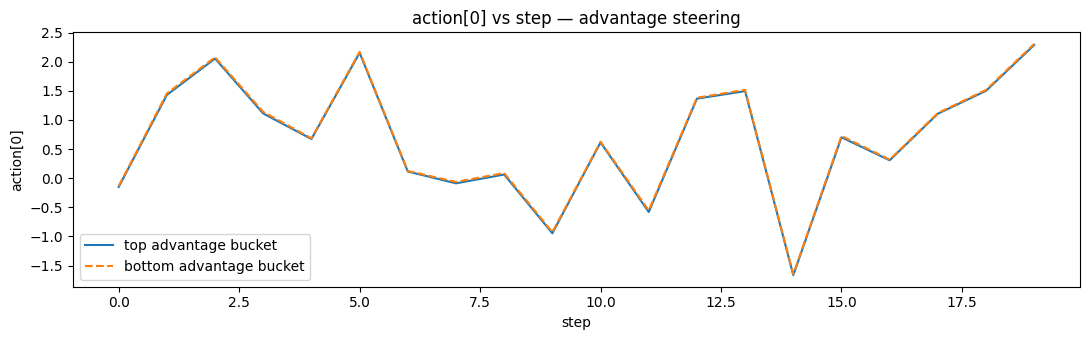

In [5]:
cond = AdvantageConditioner(RECAPConfig(advantage_bins=21, advantage_token_embed_dim=cfg.advantage_token_dim))
top_token = cond.top_bucket_token(batch_size=1, device=torch.device('cpu'))
bottom_token = cond.embed(torch.tensor([0], dtype=torch.long))

with torch.no_grad():
    torch.manual_seed(42)
    chunk_top = policy.predict_chunk(images_1, state_1, lang_1, advantage_token=top_token).squeeze(0)
    torch.manual_seed(42)
    chunk_bot = policy.predict_chunk(images_1, state_1, lang_1, advantage_token=bottom_token).squeeze(0)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(chunk_top[:, 0].numpy(), label='top advantage bucket',    lw=1.5)
ax.plot(chunk_bot[:, 0].numpy(), label='bottom advantage bucket', lw=1.5, ls='--')
ax.set(title='action[0] vs step — advantage steering', xlabel='step', ylabel='action[0]')
ax.legend(); fig.tight_layout()

## 5. MEM integration

Attach a MEM store to the policy, push some history, and recall it as conditioning tokens.

In [6]:
mem = MEM(MEMConfig(embedding_dim=32))   # MEM dim != policy hidden_size — padded in recall_memory_tokens
policy_with_mem = Pi07Policy(cfg, memory=mem)

# Simulate a kitchen scenario.
for st in [
    'pick up cutting board', 'open fridge',
    'add salt to bowl', 'close salt shaker',
    'pour olive oil into bowl',
]:
    mem.add_subtask_summary(st, frames=[np.zeros((1,))], t_start=0, t_end=1)

# Recall relevant entries and feed them as memory tokens.
memory_tokens = policy_with_mem.recall_memory_tokens('did I add salt yet?', k=3)
print('recalled memory tokens     :', memory_tokens.shape)
with torch.no_grad():
    chunk_with_mem = policy_with_mem.predict_chunk(
        images_1, state_1, lang_1,
        memory_tokens=memory_tokens,
    )
print('action chunk shape         :', chunk_with_mem.shape)

recalled memory tokens     : torch.Size([1, 3, 128])
action chunk shape         : torch.Size([1, 20, 7])


## 6. Full kitchen-sink predict_chunk

All five context channels in one call. This is what a real π₀.₇ inference loop looks like.

In [7]:
B = 2
with torch.no_grad():
    chunk = policy_with_mem.predict_chunk(
        images=torch.randn(B, 3, cfg.image_resolution, cfg.image_resolution),
        state=torch.randn(B, cfg.state_dim),
        language_ids=torch.randint(0, TINY.vocab_size, (B, 8)),
        advantage_token=cond.top_bucket_token(batch_size=B, device=torch.device('cpu')),
        subgoal_images=torch.randn(B, 1, 3, cfg.image_resolution, cfg.image_resolution),
        metadata={'speed': Speed.fast, 'quality': Quality.precise, 'persona': Persona.careful},
        memory_tokens=policy_with_mem.recall_memory_tokens('what comes next?', k=2).repeat(B, 1, 1),
    )
print('full π₀.₇ chunk shape:', chunk.shape)

full π₀.₇ chunk shape: torch.Size([2, 20, 7])


## 7. RTC integration — inpainting prefix

Pass a `prefix` to fix the first few actions while the rest are sampled. This is how `pi_stack.inference.rtc.RTCRunner` continues smoothly across chunk boundaries.

prefix values   : [0.123 0.123 0.123 0.123 0.123]
prefix held flat: True


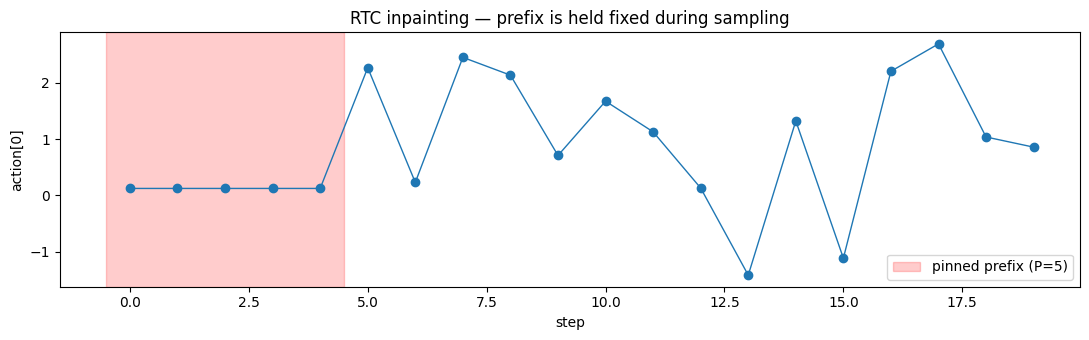

In [8]:
P = 5
prefix = torch.full((1, P, cfg.action_expert.action_dim), 0.123)
with torch.no_grad():
    chunk_rtc = policy.predict_chunk(images_1, state_1, lang_1, prefix=prefix).squeeze(0)
print('prefix values   :', chunk_rtc[:P, 0].numpy())
print('prefix held flat:', torch.allclose(chunk_rtc[:P, :], prefix.squeeze(0)))

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(chunk_rtc[:, 0].numpy(), 'o-', lw=1)
ax.axvspan(-0.5, P - 0.5, alpha=0.2, color='red', label=f'pinned prefix (P={P})')
ax.set(title='RTC inpainting — prefix is held fixed during sampling', xlabel='step', ylabel='action[0]')
ax.legend(); fig.tight_layout()

## Takeaways

- The whole π₀.₇ stack assembles from one config dataclass.
- All five context channels (image, language, state, advantage, subgoal, metadata, MEM) compose cleanly via `encode_context`.
- Metadata + advantage tokens visibly steer the action distribution.
- RTC's inpainting contract is honored end-to-end.

## Real backbone

Swap `TINY` for `GEMMA3_4B` (or `PALIGEMMA_3B` for π₀ / π₀.₅) and pass the loaded backbone:

```python
from pi_stack.models.backbones import GEMMA3_4B, load_backbone
real_backbone = load_backbone(GEMMA3_4B, device='cuda')
policy = Pi07Policy(Pi07Config(backbone=GEMMA3_4B), backbone=real_backbone)
```

Needs ≥ 12 GB VRAM. Treat full pre-training as aspirational on commodity hardware.